<a href="https://colab.research.google.com/github/jarizmendi18-source/clasificacion_de_prendas/blob/main/Gestion_FaseII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!find /content/drive -name "*.keras"

/content/drive/MyDrive/ReconocimientoPrendasIA/backend/modelo.keras


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bibliotecas para uso de imágenes
import cv2

# Bibliotecas para modelos de redes neuronales artificiales con keras
import tensorflow as tf
from tensorflow.keras.preprocessing import image as image_utils
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import backend, callbacks, optimizers
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
import tensorflow.keras.utils as np_utils
from sklearn.model_selection import train_test_split
import imutils

# Bibliotecas para transferencia de conocimiento
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Para otros modelos
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

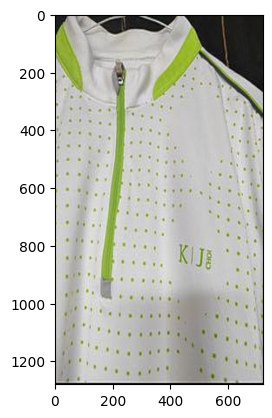

In [ ]:
imagen = image_utils.load_img('/content/drive/MyDrive/Imagenes/3.jpg')
plt.imshow(imagen, cmap='Accent')
plt.show()


In [ ]:
type(imagen)


PIL.JpegImagePlugin.JpegImageFile

In [ ]:

imagen = image_utils.img_to_array(imagen)
imagen.shape


(1280, 720, 3)

In [ ]:

n_imagenes = 1000
alto = 200
ancho = 200
canales = 3

dataset = np.zeros((n_imagenes, alto, ancho, canales), dtype = np.float32)

In [ ]:

for i in range (n_imagenes):                                  # recuerda que la cuenta es de 0 a 399
  nombre = '/content/drive/MyDrive/Imagenes/'+str(i+1)+'.jpg'      # construimos el nombre de la imagen
  img = image_utils.load_img(nombre, target_size=(alto, ancho))               # con el nombre, leemos la imagen
  img = image_utils. img_to_array(img)              # convertimos la imagen a arreglo de numpy. Esta es una buena practica
  # Preprocesamiento
  # Aquí normalizamos la imagen antes de almacenarla en el dataset
  # img = img/255 # Sin transfer learning

  # Para transfer learning
  img = preprocess_input(img)
  dataset[i] = img


In [ ]:

  lbs = pd.read_fwf('/content/drive/MyDrive/Imagenes/etiquetas.txt', header=None)
etiquetas = lbs.loc[:,0]
etiquetas


,0
0,Polo
1,Polo
2,Polo
3,Polo
4,Polo
...,...
995,jean
996,jean
997,jean
998,jean


In [ ]:

targets = np.zeros(len(etiquetas))    # Creamos un arreglo de ceros
for i in range(len(etiquetas)):      # Recorremos todas las etiquetas
  if (etiquetas[i] == 'Polo'):         # Si la etiqueta dice "perro"
    targets[i] = 1
  else:
    targets[i] = 0


In [ ]:

targets


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [ ]:


x_train, x_test, y_train, y_test = train_test_split(dataset,
                                                    targets,
                                                    test_size = 0.2,
                                                    random_state = 10)



In [ ]:
print(x_train.shape)
print(x_test.shape)


(800, 200, 200, 3)
(200, 200, 200, 3)


In [ ]:

backend.clear_session()


In [ ]:

modelo = Sequential()
modelo.add(Conv2D(4, kernel_size=(3,3), activation='relu', input_shape=(200,200,3)))
modelo.add(Dropout(0.7))
modelo.add(MaxPool2D(pool_size=(2,2)))
modelo.add(Dropout(0.8))
modelo.add(Conv2D(8,kernel_size=(3,3), activation='relu'))
modelo.add(MaxPool2D(pool_size=(2,2)))
modelo.add(Dropout(0.8))
modelo.add(Conv2D(16,kernel_size=(3,3), activation='relu'))
modelo.add(MaxPool2D(pool_size=(2,2)))
modelo.add(Conv2D(64,kernel_size=(3,3), activation='relu'))
modelo.add(MaxPool2D(pool_size=(2,2)))
modelo.add(Flatten())
modelo.add(Dropout(0.8))
modelo.add(Dense(60, activation='relu'))
modelo.add(Dropout(0.7))
modelo.add(Dense(1, activation='sigmoid'))

modelo.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 198, 198, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 99, 99, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │       384,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,977 (1.51 MB)

 Trainable params: 394,977 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

Adam = optimizers.Adam(learning_rate = 0.001)
modelo.compile(optimizer=Adam, loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:



H = modelo.fit(x_train, y_train, validation_data=(x_test, y_test),
               epochs=200, batch_size=32, verbose= True)


Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 930ms/step - accuracy: 0.4875 - loss: 296.2081 - val_accuracy: 0.4950 - val_loss: 0.7099
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 752ms/step - accuracy: 0.5063 - loss: 7.3297 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 739ms/step - accuracy: 0.5050 - loss: 2.0224 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 742ms/step - accuracy: 0.5000 - loss: 1.1160 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 799ms/step - accuracy: 0.5000 - loss: 0.9437 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 727ms/step - accuracy: 0.5038 - loss: 0.8852 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 733ms/step - accuracy: 0.5013 - loss: 0.9517 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 835ms/step - accuracy: 0.4963 - loss: 0.7911 

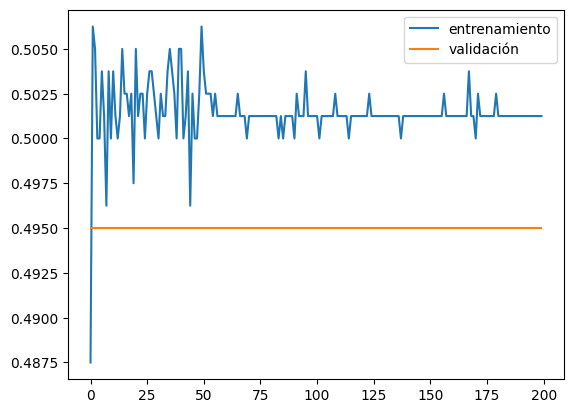

In [ ]:


plt.plot(H.history['accuracy'], label ='entrenamiento')
plt.plot(H.history['val_accuracy'], label ='validación')
plt.legend(loc='best')
plt.show()


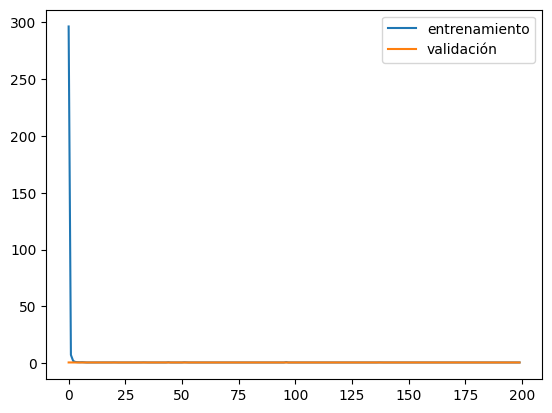

In [ ]:


plt.plot(H.history['loss'], label ='entrenamiento')
plt.plot(H.history['val_loss'], label ='validación')
plt.legend(loc='best')
plt.show()


In [ ]:

backend.clear_session()


In [ ]:

modelo_base = ResNet50(weights='imagenet', include_top=False, input_shape=(alto, ancho, canales))



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

for capa in modelo_base.layers:
  capa.trainable = False


In [ ]:

modelo_intermedio = modelo_base.output
modelo_intermedio = Flatten()(modelo_intermedio)
modelo_intermedio = Dense(200, activation='relu')(modelo_intermedio)
modelo_intermedio = Dense(1, activation='sigmoid')(modelo_intermedio)

modelo_final = Model(inputs = modelo_base.input, outputs = modelo_intermedio)



In [ ]:

modelo_final.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 43,658,513 (166.54 MB)

 Trainable params: 20,070,801 (76.56 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:

Adam = optimizers.Adam(learning_rate=0.001)
# Compilación del modelo final
modelo_final.compile(optimizer= Adam, loss='binary_crossentropy',
                     metrics=['accuracy'])



In [ ]:
checkpoint = callbacks.ModelCheckpoint(filepath='pesos.h5', monitor='val_loss',
                             verbose=1, mode = 'min', save_best_only=True)



In [ ]:
M = modelo_final.fit(x_train, y_train, epochs = 50,
                     validation_data= (x_test, y_test),
                     verbose=True, shuffle=True, batch_size=32,
                     callbacks=[checkpoint]) #suffle es para datos aleatorios




Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8241 - loss: 6.5443
Epoch 1: val_loss improved from None to 0.35447, saving model to pesos.h5



Epoch 1: finished saving model to pesos.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 174s 7s/step - accuracy: 0.9162 - loss: 3.4850 - val_accuracy: 0.9850 - val_loss: 0.3545
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9885 - loss: 0.3411
Epoch 2: val_loss did not improve from 0.35447
25/25 ━━━━━━━━━━━━━━━━━━━━ 192s 6s/step - accuracy: 0.9937 - loss: 0.1761 - val_accuracy: 0.9800 - val_loss: 0.4744
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 8.7107e-14
Epoch 3: val_loss did not improve from 0.35447
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 1.0000 - loss: 3.7687e-14 - val_accuracy: 0.9900 - val_loss: 0.3669
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9993 - loss: 0.0023
Epoch 4: val_loss did not improve from 0.35447
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9850 - val_loss: 0.5342
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9999 - loss: 0.0019
Epoch 5: va


Epoch 6: finished saving model to pesos.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 1.0000 - loss: 3.8740e-07 - val_accuracy: 0.9900 - val_loss: 0.3463
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 5.3915e-08
Epoch 7: val_loss improved from 0.34631 to 0.34452, saving model to pesos.h5



Epoch 7: finished saving model to pesos.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 1.0000 - loss: 1.6247e-07 - val_accuracy: 0.9900 - val_loss: 0.3445
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 9.8710e-09
Epoch 8: val_loss did not improve from 0.34452
25/25 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step - accuracy: 1.0000 - loss: 2.8613e-08 - val_accuracy: 0.9900 - val_loss: 0.3447
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 4.6324e-08
Epoch 9: val_loss did not improve from 0.34452
25/25 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 1.0000 - loss: 2.4046e-08 - val_accuracy: 0.9900 - val_loss: 0.3450
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 3.4417e-08
Epoch 10: val_loss did not improve from 0.34452
25/25 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 1.0000 - loss: 1.8569e-08 - val_accuracy: 0.9900 - val_loss: 0.3451
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - l

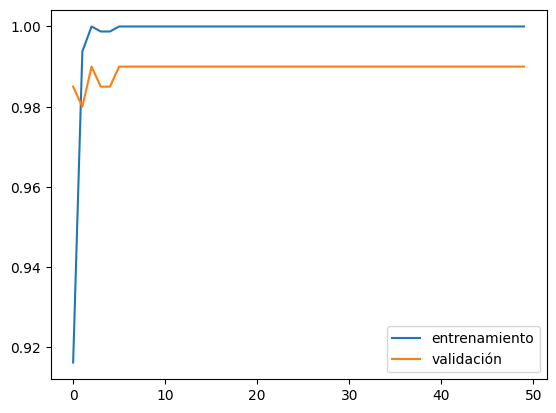

In [ ]:
plt.plot(M.history['accuracy'], label ='entrenamiento')
plt.plot(M.history['val_accuracy'], label ='validación')
plt.legend(loc='best')
plt.show()





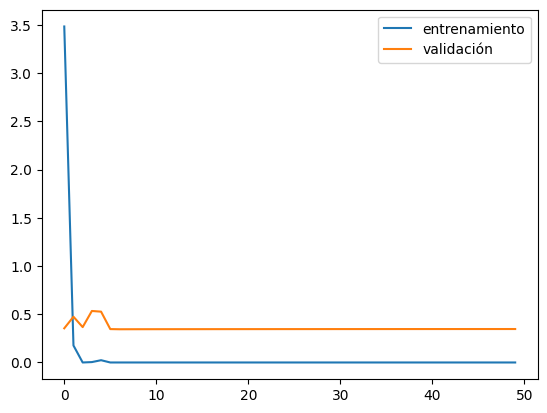

In [ ]:
plt.plot(M.history['loss'], label ='entrenamiento')
plt.plot(M.history['val_loss'], label ='validación')
plt.legend(loc='best')
plt.show()



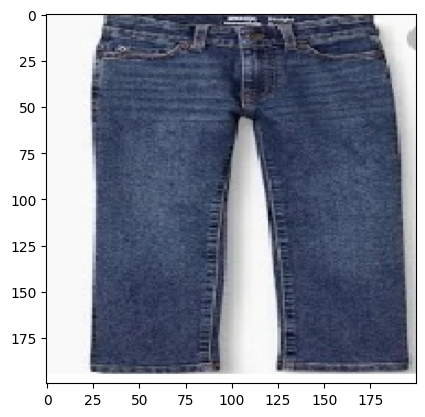

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediccion =  [[0.]]
La imagen es de unos jeans


In [ ]:
prueba = image_utils.load_img('/content/drive/MyDrive/img_nueva.jpg', target_size = (200,200))
plt.imshow(prueba, cmap = 'Accent')
prueba = image_utils.img_to_array(prueba)
plt.show()

# Predicción de la clase de la imagen
prueba = preprocess_input(prueba)
clasificacion = modelo_final.predict(prueba.reshape(1,200,200,3))

print('Prediccion = ', clasificacion)

if (clasificacion > 0.5):
  print ('La imagen es de un polo')
else:
  print('La imagen es de unos jeans')

In [ ]:
modelo.save("modelo_prendas.keras")

In [ ]:
import json

clases = [
    "Jean",
    "Polo"
]

with open("clases.json", "w") as f:
    json.dump(clases, f)

print("Archivo de clases creado.")

Archivo de clases creado.


In [ ]:
files.download("clases.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loss, accuracy = modelo_final.evaluate(x_test, y_test)

print(f"Pérdida: {loss:.4f}")
print(f"Precisión: {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.9900 - loss: 0.3470
Pérdida: 0.3470
Precisión: 0.9900


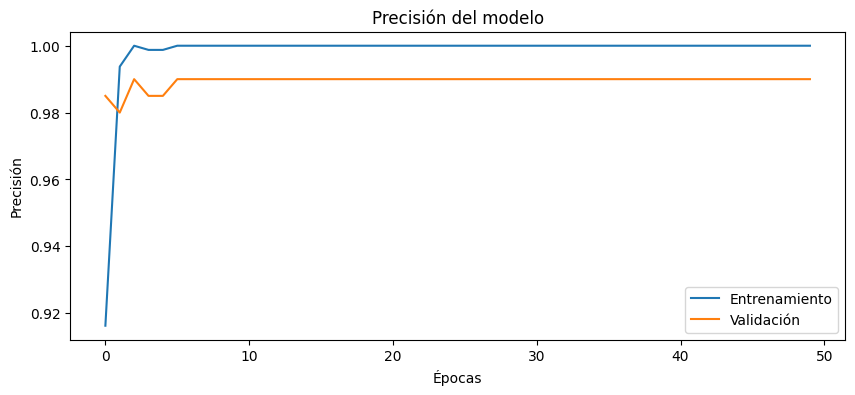

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(M.history["accuracy"], label="Entrenamiento")
plt.plot(M.history["val_accuracy"], label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.title("Precisión del modelo")
plt.legend()

plt.show()

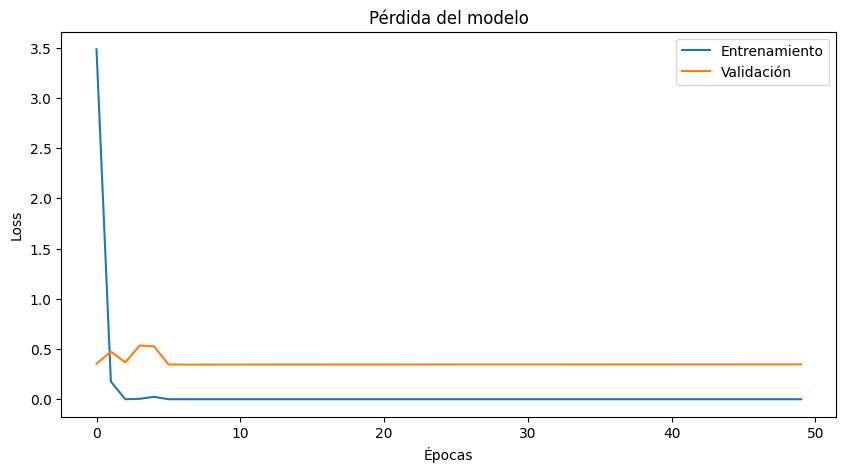

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(M.history["loss"], label="Entrenamiento")
plt.plot(M.history["val_loss"], label="Validación")

plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
import pandas as pd

historial = pd.DataFrame(M.history)

historial.to_csv("historial_entrenamiento.csv", index=False)

print("Historial guardado correctamente.")

Historial guardado correctamente.


In [ ]:
print(M.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
import os

os.listdir("/content")

['.config', 'modelo_prendas.keras', 'pesos.h5', 'drive', 'sample_data']

In [ ]:
from google.colab import files
files.download("modelo_prendas.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

ruta = "/content/drive/MyDrive/ReconocimientoPrendasIA"

carpetas = [
    "backend",
    "frontend",
    "model",
    "static",
    "tests",
    "docs",
    "screenshots"
]

for carpeta in carpetas:
    os.makedirs(os.path.join(ruta, carpeta), exist_ok=True)

print("Proyecto creado correctamente.")

Proyecto creado correctamente.


In [ ]:
%who

Adam	 Conv2D	 Dense	 Dropout	 Flatten	 H	 M	 MaxPool2D	 MobileNet	 
Model	 ResNet50	 Sequential	 VGG19	 alto	 ancho	 backend	 callbacks	 canales	 
capa	 carpeta	 carpetas	 checkpoint	 clasificacion	 cv2	 dataset	 drive	 etiquetas	 
files	 i	 image_utils	 imagen	 img	 imutils	 lbs	 modelo	 modelo_base	 
modelo_final	 modelo_intermedio	 n_imagenes	 nombre	 np	 np_utils	 optimizers	 os	 pd	 
plt	 preprocess_input	 prueba	 ruta	 targets	 tf	 train_test_split	 x_test	 x_train	 
y_test	 y_train	 


In [ ]:
modelo_final.save("modelo_prendas.keras")

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'modelo_prendas.keras', 'pesos.h5', 'drive', 'sample_data']


In [ ]:
modelo_final.save("modelo.keras")

In [ ]:
from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np

app = FastAPI()

modelo = load_model("modelo.keras")

clases = [
    "JEAN",
    "POLO"

]

@app.get("/")
def inicio():
    return {"mensaje":"API funcionando"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    imagen = Image.open(file.file)

    imagen = imagen.resize((150,150))

    imagen = np.array(imagen)

    imagen = imagen/255

    imagen = np.expand_dims(imagen,axis=0)

    pred = modelo.predict(imagen)

    clase = clases[np.argmax(pred)]

    confianza = float(np.max(pred))

    return{
        "clase":clase,
        "confianza":confianza
    }

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html lang="es">

<head>
    <meta charset="UTF-8">
    <title>Clasificador de Ropa</title>
    <link rel="stylesheet" href="style.css">
</head>

<body>

<h1>Clasificador de prendas con IA</h1>

<p>Seleccione una imagen</p>

<input type="file" id="imagen">

<br><br>

<button onclick="enviar()">
Clasificar
</button>

<h2 id="resultado"></h2>

<script src="script.js"></script>

</body>

</html>

Writing index.html


In [ ]:
!ls

clases.json  historial_entrenamiento.csv  modelo.keras		pesos.h5
drive	     index.html			  modelo_prendas.keras	sample_data


In [ ]:
%%writefile style.css

body{
    font-family:Arial;
    text-align:center;
}

Writing style.css


In [ ]:
%%writefile script.js

console.log("Frontend funcionando");

Writing script.js


In [ ]:
%%writefile style.css

body{
    font-family: Arial;
    text-align: center;
    margin-top: 40px;
    background-color: #f4f4f4;
}

h1{
    color:#1976D2;
}

button{
    background-color:#1976D2;
    color:white;
    border:none;
    padding:12px 20px;
    cursor:pointer;
    font-size:16px;
}

button:hover{
    background-color:#0D47A1;
}

#resultado{
    margin-top:20px;
    font-size:22px;
    color:green;
}

Overwriting style.css


In [ ]:
%%writefile script.js

async function enviar(){

    const archivo = document.getElementById("imagen").files[0];

    if(!archivo){
        alert("Seleccione una imagen.");
        return;
    }

    let datos = new FormData();

    datos.append("file", archivo);

    const respuesta = await fetch(
        "http://localhost:8000/predict",
        {
            method:"POST",
            body:datos
        }
    );

    const resultado = await respuesta.json();

    document.getElementById("resultado").innerHTML =
    "Clase: " + resultado.clase +
    "<br>Confianza: " + (resultado.confianza*100).toFixed(2) + "%";
}

Overwriting script.js


In [ ]:
!ls

clases.json		     index.html		   pesos.h5	style.css
drive			     modelo.keras	   sample_data
historial_entrenamiento.csv  modelo_prendas.keras  script.js


In [ ]:
modelo = load_model("modelo.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
!pip install fastapi uvicorn python-multipart nest_asyncio pyngrok

In [ ]:
%%writefile app.py

from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import json

app = FastAPI()

# Cargar el modelo
modelo = load_model("modelo.keras")

# Cargar las clases desde el archivo JSON
with open("clases.json", "r") as f:
    clases = json.load(f)

@app.get("/")
def inicio():
    return {"mensaje": "API funcionando correctamente"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    imagen = Image.open(file.file).convert("RGB")

    # Cambia (150,150) por el tamaño que usaste al entrenar el modelo
    imagen = imagen.resize((150,150))

    imagen = np.array(imagen)/255.0
    imagen = np.expand_dims(imagen, axis=0)

    pred = modelo.predict(imagen)

    indice = np.argmax(pred)

    return {
        "clase": clases[indice],
        "confianza": float(np.max(pred))
    }

Writing app.py


In [ ]:
!ls *.py

app.py


In [ ]:
!ls

app.py	     historial_entrenamiento.csv  modelo_prendas.keras	script.js
clases.json  index.html			  pesos.h5		style.css
drive	     modelo.keras		  sample_data


In [ ]:
imagen = imagen.resize((150,150))

In [ ]:
modelo_final.save("modelo.keras")

In [ ]:
from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import json

app = FastAPI()

modelo = load_model("modelo.keras")

with open("clases.json", "r") as f:
    clases = json.load(f)

@app.get("/")
def home():
    return {"message": "API funcionando"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    img = Image.open(file.file).convert("RGB")
    img = img.resize((200, 200))   # IMPORTANTE: mismo tamaño de entrenamiento

    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = modelo.predict(img)

    clase = clases[int(pred[0] > 0.5)]
    confianza = float(pred[0])

    return {"clase": clase, "confianza": confianza}

In [ ]:
%%writefile requirements.txt
fastapi
uvicorn
tensorflow
numpy
pillow
python-multipart


Writing requirements.txt


In [ ]:
!ls

app.py	     historial_entrenamiento.csv  modelo_prendas.keras	sample_data
clases.json  index.html			  pesos.h5		script.js
drive	     modelo.keras		  requirements.txt	style.css


In [ ]:
import os
import shutil

# Crear carpetas
os.makedirs("backend", exist_ok=True)
os.makedirs("frontend", exist_ok=True)

# =========================
# 📦 BACKEND
# =========================
backend_files = [
    "app.py",
    "modelo.keras",
    "clases.json"
]

for file in backend_files:
    if os.path.exists(file):
        shutil.move(file, f"backend/{file}")
        print(f"Movido a backend: {file}")

# =========================
# 🌐 FRONTEND
# =========================
frontend_files = [
    "index.html",
    "style.css",
    "script.js"
]

for file in frontend_files:
    if os.path.exists(file):
        shutil.move(file, f"frontend/{file}")
        print(f"Movido a frontend: {file}")

print("\n✅ Organización completada")

Movido a backend: app.py
Movido a backend: modelo.keras
Movido a backend: clases.json
Movido a frontend: index.html
Movido a frontend: style.css
Movido a frontend: script.js

✅ Organización completada


In [ ]:
from tensorflow.keras.models import load_model

modelo = load_model("modelo_prendas.keras")

print("Input Shape:", modelo.input_shape)
print("Output Shape:", modelo.output_shape)

ValueError: File not found: filepath=modelo_prendas.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
!ls


sample_data
